# Task 1 MusicCaps Caption Tag Classification

Goal

Use DistilBERT to read a MusicCaps caption and predict multiple context tags.

Main steps

1. Load and clean MusicCaps.
2. Create training, validation, and test splits.
3. Build the tag vocabulary from training data only.
4. Tokenize captions with DistilBERT.
5. Fine tune DistilBERT with binary cross entropy loss.
6. Select the probability threshold using validation data only.
7. Evaluate once on the held out test set.
8. Save all tables, plots, examples, configuration files, and split files into one folder.


In [1]:
# CELL 1  Install required packages

!pip -q install -U     "datasets>=3.0,<5"     "transformers>=4.45,<5"     "accelerate>=1.0"     "scikit-learn>=1.4"     "iterative-stratification>=0.1.9"

print("Required packages are ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 98.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 110.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.1 which is incompatible.
Required packages are ready.


In [2]:
# CELL 2 - Imports, reproducibility, and a real CUDA preflight

import os
import re
import ast                                                            
import json
import random
import warnings
from pathlib import Path
from collections import Counter
from contextlib import nullcontext
import copy
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

SEED = 42

def cuda_preflight():
    info = {
        "torch_version": torch.__version__,
        "torch_cuda_build": torch.version.cuda,
        "cuda_detected": torch.cuda.is_available(),
    }

    if not torch.cuda.is_available():
        info["reason"] = "CUDA not detected."
        return False, info

    try:
        idx = torch.cuda.current_device()
        info["gpu_name"] = torch.cuda.get_device_name(idx)
        info["compute_capability"] = torch.cuda.get_device_capability(idx)
        info["compiled_arch_list"] = torch.cuda.get_arch_list()

        # This catches architecture/kernel incompatibility immediately.
        x = torch.tensor([1.0, 2.0, 3.0], device="cuda")
        y = (x * 2).sum()
        torch.cuda.synchronize()
        info["test_value"] = float(y.cpu())
        info["reason"] = "Real CUDA tensor operation succeeded."
        return True, info
    except Exception as e:
        info["reason"] = repr(e)
        return False, info

CUDA_USABLE, CUDA_INFO = cuda_preflight()
DEVICE = torch.device("cuda" if CUDA_USABLE else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)

    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

print("=" * 72)
print("ENVIRONMENT")
print("=" * 72)
for key, value in CUDA_INFO.items():
    print(f"{key:24s}: {value}")
print("selected device         :", DEVICE)
print("seed                    :", SEED)
print("=" * 72)

if DEVICE.type == "cpu":
    print("CUDA was not usable. The notebook will run on CPU instead of crashing.")

ENVIRONMENT
torch_version           : 2.10.0+cu128
torch_cuda_build        : 12.8
cuda_detected           : True
gpu_name                : Tesla T4
compute_capability      : (7, 5)
compiled_arch_list      : ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
test_value              : 12.0
reason                  : Real CUDA tensor operation succeeded.
selected device         : cuda
seed                    : 42


# Configuration

Important values are stored in one place.

The output folder is organized for GitHub. It contains split files, metrics, plots, examples, configuration files, a README file, and a requirements file.

In [3]:
# CELL 3  Experiment configuration and output folders

DATASET_NAME = "google/MusicCaps"
MODEL_NAME = "distilbert-base-uncased"

TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
TEST_FRAC = 0.10

MIN_TRAIN_SUPPORT = 100

BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 2

LOSS_NAME = "BCEWithLogitsLoss"

FAST_DEV_RUN = False
FAST_DEV_ROWS = 1000
FAST_DEV_EPOCHS = 1

PROJECT_DIR = Path("/kaggle/working/task1_musiccaps_github")

if not Path("/kaggle/working").exists():
    PROJECT_DIR = Path("./task1_musiccaps_github")

SPLITS_DIR = PROJECT_DIR / "data_splits"
METRICS_DIR = PROJECT_DIR / "metrics"
PLOTS_DIR = PROJECT_DIR / "plots"
EXAMPLES_DIR = PROJECT_DIR / "examples"
CONFIG_DIR = PROJECT_DIR / "config"

for folder in [
    PROJECT_DIR,
    SPLITS_DIR,
    METRICS_DIR,
    PLOTS_DIR,
    EXAMPLES_DIR,
    CONFIG_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_NAME)
print("Model:", MODEL_NAME)
print("Minimum training support:", MIN_TRAIN_SUPPORT)
print("Batch size:", BATCH_SIZE)
print("Maximum training epochs:", FAST_DEV_EPOCHS if FAST_DEV_RUN else EPOCHS)
print("Loss:", LOSS_NAME)
print("Project output folder:", PROJECT_DIR.resolve())

Dataset: google/MusicCaps
Model: distilbert-base-uncased
Minimum training support: 100
Batch size: 32
Maximum training epochs: 10
Loss: BCEWithLogitsLoss
Project output folder: /kaggle/working/task1_musiccaps_github


# Load and check MusicCaps

MusicCaps contains expert written captions and aspect phrases.

The notebook removes exact duplicate clips and checks that the fields required by Task 1 are present.

In [4]:
# CELL 4 - Load official MusicCaps metadata

print("Loading:", DATASET_NAME)

dataset = load_dataset(DATASET_NAME, split="train")
df = dataset.to_pandas()

print("\nDataset loaded.")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head(3))

Loading: google/MusicCaps


README.md: 0.00B [00:00, ?B/s]

musiccaps-public.csv:   0%|          | 0.00/2.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5521 [00:00<?, ? examples/s]


Dataset loaded.
Shape: (5521, 9)
Columns: ['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval']


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True


In [5]:
# CELL 5 - Validate expected schema

EXPECTED_COLUMNS = {
    "ytid",
    "start_s",
    "end_s",
    "audioset_positive_labels",
    "aspect_list",
    "caption",
    "author_id",
    "is_balanced_subset",
    "is_audioset_eval",
}

missing = EXPECTED_COLUMNS - set(df.columns)

if missing:
    raise ValueError(f"Missing expected columns: {sorted(missing)}")

print("Schema check passed.")
print("\nDtypes:")
print(df.dtypes)

print("\nFirst row:")
for col in df.columns:
    print(f"{col}: {df.iloc[0][col]}")

Schema check passed.

Dtypes:
ytid                        object
start_s                      int64
end_s                        int64
audioset_positive_labels    object
aspect_list                 object
caption                     object
author_id                    int64
is_balanced_subset            bool
is_audioset_eval              bool
dtype: object

First row:
ytid: -0Gj8-vB1q4
start_s: 30
end_s: 40
audioset_positive_labels: /m/0140xf,/m/02cjck,/m/04rlf
aspect_list: ['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']
caption: The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.
author_id: 4
is_balanced_subset: False
is_audioset_eval: True


In [6]:
# CELL 6 - Data-integrity audit

duration = (
    pd.to_numeric(df["end_s"], errors="coerce")
    - pd.to_numeric(df["start_s"], errors="coerce")
)

clip_key = (
    df["ytid"].astype(str)
    + "__"
    + df["start_s"].astype(str)
    + "__"
    + df["end_s"].astype(str)
)

normalized_caption = (
    df["caption"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

audit = {
    "rows": len(df),
    "missing_caption": int(df["caption"].isna().sum()),
    "missing_aspect_list": int(df["aspect_list"].isna().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_ytid": int(df["ytid"].duplicated().sum()),
    "duplicate_clip_key": int(clip_key.duplicated().sum()),
    "duplicate_normalized_caption": int(normalized_caption.duplicated().sum()),
}

print("=" * 88)
print("DATA-INTEGRITY AUDIT")
print("=" * 88)

for key, value in audit.items():
    print(f"{key:34s}: {value}")

print("\nClip duration:")
print(duration.describe())

print("\nauthor_id counts:")
print(df["author_id"].value_counts(dropna=False).sort_index())

print("\nImportant:")
print("author_id identifies the caption writer, not the musical artist.")

DATA-INTEGRITY AUDIT
rows                              : 5521
missing_caption                   : 0
missing_aspect_list               : 0
duplicate_rows                    : 0
duplicate_ytid                    : 0
duplicate_clip_key                : 0
duplicate_normalized_caption      : 0

Clip duration:
count    5521.0
mean       10.0
std         0.0
min        10.0
25%        10.0
50%        10.0
75%        10.0
max        10.0
dtype: float64

author_id counts:
author_id
0     554
1     489
2     112
3     301
4    1383
5      33
6     895
7     708
8     180
9     866
Name: count, dtype: int64

Important:
author_id identifies the caption writer, not the musical artist.


In [7]:
# CELL 7 - Clean required fields and prevent exact duplicate leakage

work_df = df.copy()
before = len(work_df)

work_df = work_df.dropna(
    subset=["ytid", "start_s", "end_s", "caption", "aspect_list"]
).copy()

work_df["caption"] = work_df["caption"].astype(str).str.strip()
work_df["aspect_list"] = work_df["aspect_list"].astype(str).str.strip()

work_df = work_df[
    work_df["caption"].str.len().gt(0)
    & work_df["aspect_list"].str.len().gt(0)
].copy()

work_df["clip_key"] = (
    work_df["ytid"].astype(str)
    + "__"
    + work_df["start_s"].astype(str)
    + "__"
    + work_df["end_s"].astype(str)
)

work_df["normalized_caption"] = (
    work_df["caption"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

duplicate_clips = int(work_df["clip_key"].duplicated().sum())
duplicate_captions = int(work_df["normalized_caption"].duplicated().sum())

work_df = work_df.drop_duplicates(
    subset=["clip_key"],
    keep="first",
).copy()

work_df = work_df.drop_duplicates(
    subset=["normalized_caption"],
    keep="first",
).copy()

work_df = work_df.reset_index(drop=True)

if FAST_DEV_RUN and len(work_df) > FAST_DEV_ROWS:
    work_df = work_df.sample(
        FAST_DEV_ROWS,
        random_state=SEED,
    ).reset_index(drop=True)

print("Rows before                    :", before)
print("Duplicate clip keys removed    :", duplicate_clips)
print("Duplicate captions removed     :", duplicate_captions)
print("Rows after cleaning             :", len(work_df))
print("Unique clip keys                :", work_df["clip_key"].nunique())

Rows before                    : 5521
Duplicate clip keys removed    : 0
Duplicate captions removed     : 0
Rows after cleaning             : 5521
Unique clip keys                : 5521


In [8]:
# CELL 8 - Parse aspect_list and AudioSet source labels

def parse_python_list(value):
    if isinstance(value, (list, tuple)):
        return [str(x).strip() for x in value if str(x).strip()]

    try:
        parsed = ast.literal_eval(str(value))
        if isinstance(parsed, (list, tuple)):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except (ValueError, SyntaxError):
        pass

    return [
        x.strip()
        for x in str(value).split(",")
        if x.strip()
    ]

def normalize_aspect_phrase(text):
    # Minimal normalization only.
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

def parse_audioset_labels(value):
    # MusicCaps stores AudioSet IDs as comma-separated strings.
    if pd.isna(value):
        return []
    return [
        x.strip()
        for x in str(value).split(",")
        if x.strip()
    ]

work_df["raw_aspects"] = work_df["aspect_list"].apply(parse_python_list)
work_df["aspects"] = work_df["raw_aspects"].apply(
    lambda xs: list(dict.fromkeys(
        normalize_aspect_phrase(x)
        for x in xs
        if normalize_aspect_phrase(x)
    ))
)

work_df["audioset_ids"] = work_df["audioset_positive_labels"].apply(
    parse_audioset_labels
)

work_df["n_aspects"] = work_df["aspects"].apply(len)
work_df["caption_words"] = work_df["caption"].str.split().str.len()

print("Example caption:")
print(work_df.iloc[0]["caption"])

print("\nOriginal aspects:")
print(work_df.iloc[0]["raw_aspects"])

print("\nMinimally normalized aspects:")
print(work_df.iloc[0]["aspects"])

print("\nAudioSet IDs:")
print(work_df.iloc[0]["audioset_ids"])

Example caption:
The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.

Original aspects:
['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']

Minimally normalized aspects:
['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']

AudioSet IDs:
['/m/0140xf', '/m/02cjck', '/m/04rlf']


# Explore captions and aspect labels

These plots help explain the dataset.

Note down the caption length, number of aspect phrases, and the long tail label distribution.

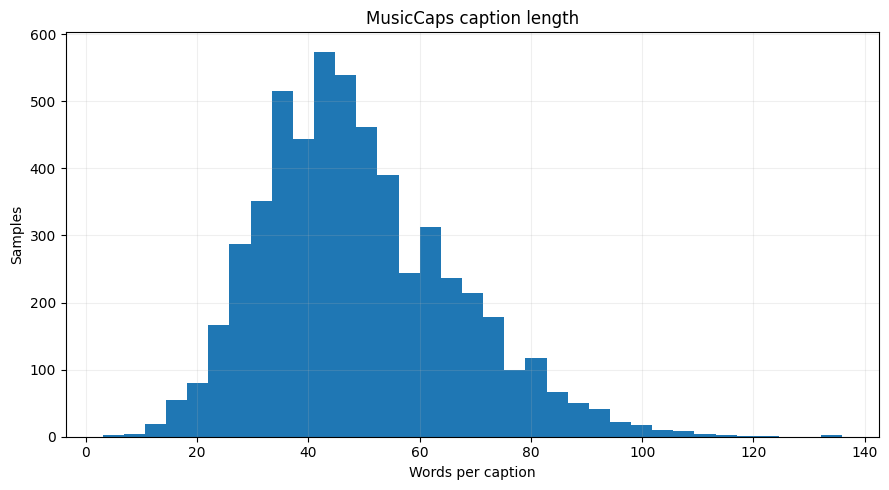

count    5521.000000
mean       48.968303
std        17.329780
min         3.000000
25%        37.000000
50%        46.000000
75%        60.000000
max       136.000000
Name: caption_words, dtype: float64

Percentiles:
0.50    46.0
0.75    60.0
0.90    73.0
0.95    81.0
0.99    96.8
Name: caption_words, dtype: float64


In [9]:
# CELL 9 - EDA: caption length

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(work_df["caption_words"], bins=35)
ax.set_title("MusicCaps caption length")
ax.set_xlabel("Words per caption")
ax.set_ylabel("Samples")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "caption_length_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

print(work_df["caption_words"].describe())
print("\nPercentiles:")
print(work_df["caption_words"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

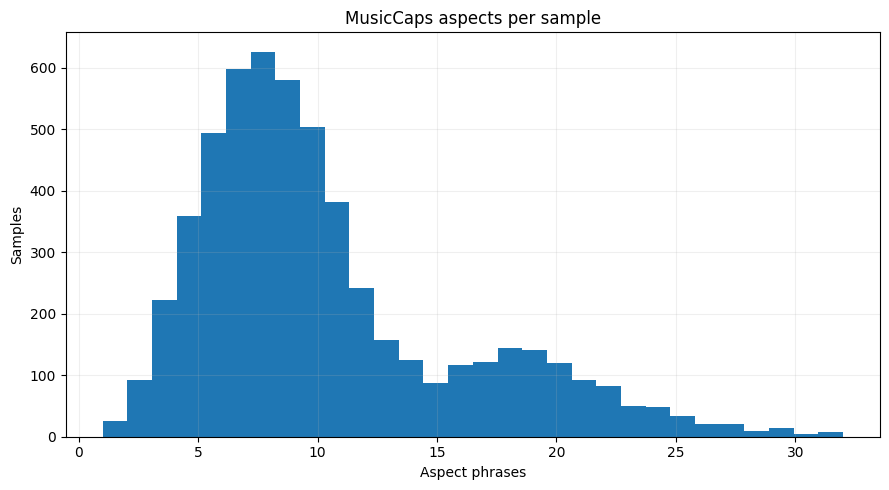

count    5521.000000
mean       10.564209
std         5.408988
min         1.000000
25%         7.000000
50%         9.000000
75%        13.000000
max        32.000000
Name: n_aspects, dtype: float64


In [10]:
# CELL 10 - EDA: number of aspects per sample

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(work_df["n_aspects"], bins=30)
ax.set_title("MusicCaps aspects per sample")
ax.set_xlabel("Aspect phrases")
ax.set_ylabel("Samples")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "aspects_per_sample.png", dpi=180, bbox_inches="tight")
plt.show()

print(work_df["n_aspects"].describe())

Unique minimally normalized aspect phrases: 13197


,aspect,count
0,low quality,1217
1,instrumental,907
2,noisy,626
3,emotional,620
4,medium tempo,596
5,energetic,593
6,passionate,592
7,amateur recording,515
8,slow tempo,473
9,live performance,469


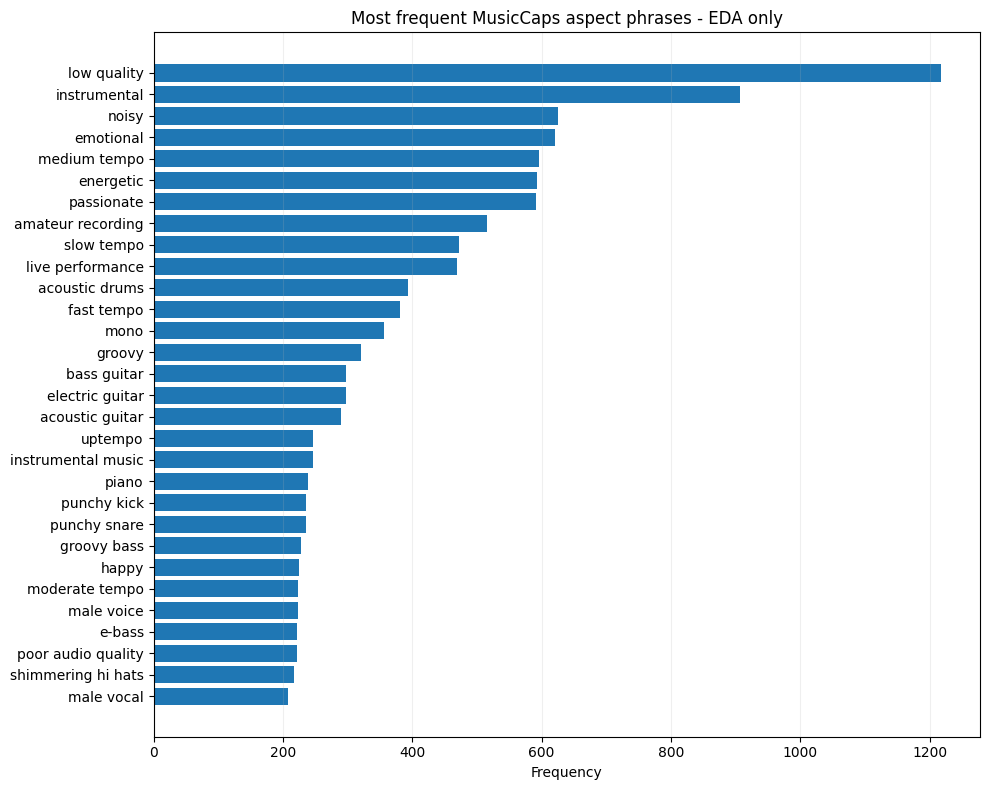


The final target vocabulary is NOT selected from this full-dataset frequency table.


In [11]:
# CELL 11 - EDA: raw aspect frequency and long tail

aspect_counter_full = Counter(
    aspect
    for aspects in work_df["aspects"]
    for aspect in aspects
)

print("Unique minimally normalized aspect phrases:", len(aspect_counter_full))

top40_eda = pd.DataFrame(
    aspect_counter_full.most_common(40),
    columns=["aspect", "count"],
)

display(top40_eda)

plot_df = top40_eda.head(30).sort_values("count")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["aspect"], plot_df["count"])
ax.set_title("Most frequent MusicCaps aspect phrases - EDA only")
ax.set_xlabel("Frequency")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "aspect_frequency_top30.png", dpi=180, bbox_inches="tight")
plt.show()

print(
    "\nThe final target vocabulary is NOT selected from this full-dataset frequency table."
)

# Create training validation and test splits

The split is created before selecting the final target tags.

AudioSet positive label identifiers are used only to balance the split. They are not prediction targets.

The notebook checks that exact clips and normalized captions do not overlap across the three splits.

In [12]:
# CELL 12 - Build an AudioSet-label matrix for splitting only

mlb_source = MultiLabelBinarizer()
Y_source = mlb_source.fit_transform(work_df["audioset_ids"])

print("AudioSet source-label matrix shape:", Y_source.shape)
print("Number of distinct AudioSet IDs:", len(mlb_source.classes_))
print("Mean AudioSet labels per clip:", Y_source.sum(axis=1).mean())

AudioSet source-label matrix shape: (5521, 346)
Number of distinct AudioSet IDs: 346
Mean AudioSet labels per clip: 3.201593914145988


In [13]:
# CELL 13 - Iterative multi-label 80/10/10 split

split1 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_FRAC + TEST_FRAC,
    random_state=SEED,
)

train_idx, temp_idx = next(
    split1.split(np.zeros(len(work_df)), Y_source)
)

temp_y_source = Y_source[temp_idx]

split2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    random_state=SEED,
)

val_rel, test_rel = next(
    split2.split(np.zeros(len(temp_idx)), temp_y_source)
)

val_idx = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

train_df = work_df.iloc[train_idx].reset_index(drop=True)
val_df = work_df.iloc[val_idx].reset_index(drop=True)
test_df = work_df.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df), f"({len(train_df)/len(work_df):.2%})")
print("Val  :", len(val_df), f"({len(val_df)/len(work_df):.2%})")
print("Test :", len(test_df), f"({len(test_df)/len(work_df):.2%})")

print("\nIndex overlap:")
print("train ∩ val :", len(set(train_idx) & set(val_idx)))
print("train ∩ test:", len(set(train_idx) & set(test_idx)))
print("val ∩ test  :", len(set(val_idx) & set(test_idx)))

Train: 4438 (80.38%)
Val  : 503 (9.11%)
Test : 580 (10.51%)

Index overlap:
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0


In [14]:
# CELL 14 - Explicit split leakage checks

def overlap_count(a, b):
    return len(set(a) & set(b))

print("=" * 88)
print("SPLIT LEAKAGE AUDIT")
print("=" * 88)

print("clip_key overlap")
print("train/val :", overlap_count(train_df["clip_key"], val_df["clip_key"]))
print("train/test:", overlap_count(train_df["clip_key"], test_df["clip_key"]))
print("val/test  :", overlap_count(val_df["clip_key"], test_df["clip_key"]))

print("\nnormalized-caption overlap")
print(
    "train/val :",
    overlap_count(train_df["normalized_caption"], val_df["normalized_caption"]),
)
print(
    "train/test:",
    overlap_count(train_df["normalized_caption"], test_df["normalized_caption"]),
)
print(
    "val/test  :",
    overlap_count(val_df["normalized_caption"], test_df["normalized_caption"]),
)

SPLIT LEAKAGE AUDIT
clip_key overlap
train/val : 0
train/test: 0
val/test  : 0

normalized-caption overlap
train/val : 0
train/test: 0
val/test  : 0


# Build the Task 1 tag vocabulary

MusicCaps aspect phrases are open vocabulary.

Only labels with at least 100 positive examples in the training split are kept. Validation and test data are not used to choose the label vocabulary.

Unique aspect phrases observed in training: 11298


,aspect,train_support
0,low quality,980
1,instrumental,723
2,emotional,499
3,noisy,490
4,energetic,480
...,...,...
95,flute,64
96,vocal harmony,64
97,sad,62
98,ambient,61


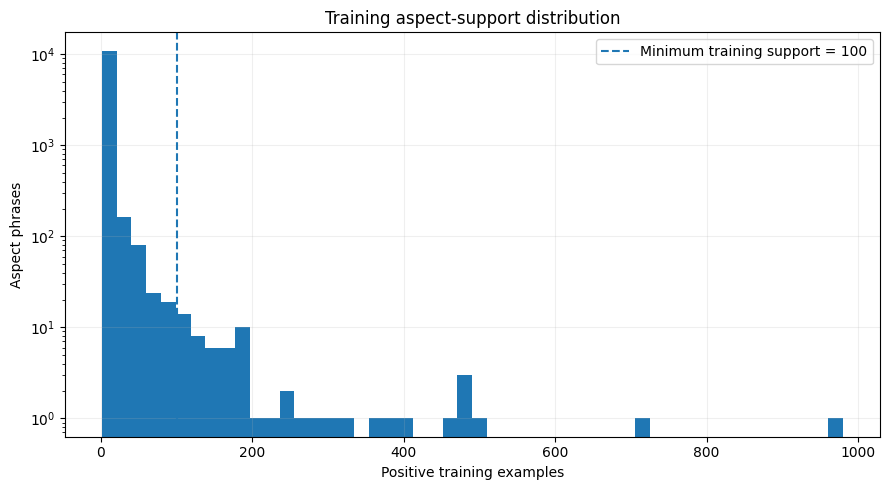

In [15]:
# CELL 15 - Training-only aspect support table

train_aspect_counter = Counter(
    aspect
    for aspects in train_df["aspects"]
    for aspect in aspects
)

support_table = pd.DataFrame(
    train_aspect_counter.items(),
    columns=["aspect", "train_support"],
).sort_values(
    ["train_support", "aspect"],
    ascending=[False, True],
).reset_index(drop=True)

print("Unique aspect phrases observed in training:", len(support_table))
display(support_table.head(100))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    support_table["train_support"],
    bins=50,
)
ax.axvline(
    MIN_TRAIN_SUPPORT,
    linestyle="--",
    label=f"Minimum training support = {MIN_TRAIN_SUPPORT}",
)
ax.set_title("Training aspect-support distribution")
ax.set_xlabel("Positive training examples")
ax.set_ylabel("Aspect phrases")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_label_support_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

In [16]:
# CELL 16 - Select supported target labels

selected_tags = support_table.loc[
    support_table["train_support"] >= MIN_TRAIN_SUPPORT,
    "aspect",
].tolist()

if len(selected_tags) < 2:
    raise RuntimeError(
        "The support threshold retained too few labels. "
        "Inspect CELL 15 before changing MIN_TRAIN_SUPPORT."
    )

tag_to_id = {
    tag: i
    for i, tag in enumerate(selected_tags)
}
id_to_tag = {
    i: tag
    for tag, i in tag_to_id.items()
}

NUM_LABELS = len(selected_tags)

print("=" * 88)
print("FINAL MUSICCAPS PROXY LABEL SET")
print("=" * 88)
print("Selection rule: training support >=", MIN_TRAIN_SUPPORT)
print("Number of retained labels:", NUM_LABELS)

selected_support = support_table[
    support_table["aspect"].isin(selected_tags)
].copy()

display(selected_support)

FINAL MUSICCAPS PROXY LABEL SET
Selection rule: training support >= 100
Number of retained labels: 62


,aspect,train_support
0,low quality,980
1,instrumental,723
2,emotional,499
3,noisy,490
4,energetic,480
...,...,...
57,melodic singing,104
58,electronic music,103
59,groovy bass line,103
60,medium to uptempo,103


In [17]:
# CELL 17 - Encode train/validation/test multi-hot targets

def encode_multihot(aspects):
    y = np.zeros(NUM_LABELS, dtype=np.float32)

    for aspect in aspects:
        idx = tag_to_id.get(aspect)
        if idx is not None:
            y[idx] = 1.0

    return y

Y_train = np.stack(
    train_df["aspects"].apply(encode_multihot).values
)
Y_val = np.stack(
    val_df["aspects"].apply(encode_multihot).values
)
Y_test = np.stack(
    test_df["aspects"].apply(encode_multihot).values
)

label_support_df = pd.DataFrame({
    "label_id": range(NUM_LABELS),
    "tag": selected_tags,
    "train_pos": Y_train.sum(axis=0).astype(int),
    "val_pos": Y_val.sum(axis=0).astype(int),
    "test_pos": Y_test.sum(axis=0).astype(int),
})

print("Label matrices:")
print("Y_train:", Y_train.shape)
print("Y_val  :", Y_val.shape)
print("Y_test :", Y_test.shape)

display(label_support_df)

print("Labels with zero validation positives:")
print(label_support_df.loc[label_support_df.val_pos == 0, "tag"].tolist())

print("\nLabels with zero test positives:")
print(label_support_df.loc[label_support_df.test_pos == 0, "tag"].tolist())

Label matrices:
Y_train: (4438, 62)
Y_val  : (503, 62)
Y_test : (580, 62)


,label_id,tag,train_pos,val_pos,test_pos
0,0,low quality,980,96,141
1,1,instrumental,723,95,89
2,2,emotional,499,59,62
3,3,noisy,490,58,78
4,4,energetic,480,61,52
...,...,...,...,...,...
57,57,melodic singing,104,15,10
58,58,electronic music,103,12,13
59,59,groovy bass line,103,13,10
60,60,medium to uptempo,103,10,14


Labels with zero validation positives:
[]

Labels with zero test positives:
[]


In [18]:
# CELL 18 - Target density and coverage

def target_report(name, y):
    positives = y.sum(axis=1)

    print(name)
    print("  samples               :", len(y))
    print("  mean positives/sample :", float(positives.mean()))
    print("  median positives      :", float(np.median(positives)))
    print("  zero-target rows      :", int((positives == 0).sum()))
    print("  positive density      :", float(y.mean()))

print("=" * 88)
print("TARGET COVERAGE")
print("=" * 88)
target_report("TRAIN", Y_train)
target_report("VALIDATION", Y_val)
target_report("TEST", Y_test)

print(
    "\nRows with zero retained labels are kept because they are legitimate negative "
    "examples for the retained proxy label vocabulary."
)

TARGET COVERAGE
TRAIN
  samples               : 4438
  mean positives/sample : 3.075259208679199
  median positives      : 3.0
  zero-target rows      : 349
  positive density      : 0.049600955098867416
VALIDATION
  samples               : 503
  mean positives/sample : 3.2544732093811035
  median positives      : 3.0
  zero-target rows      : 37
  positive density      : 0.05249150097370148
TEST
  samples               : 580
  mean positives/sample : 2.9948275089263916
  median positives      : 3.0
  zero-target rows      : 57
  positive density      : 0.048303671181201935

Rows with zero retained labels are kept because they are legitimate negative examples for the retained proxy label vocabulary.


In [19]:
# CELL 19 - Save split metadata for later Tasks 2-4

def attach_selected_tags(frame, y, split_name):
    out = frame.copy()

    out["selected_tags"] = [
        [
            id_to_tag[j]
            for j, value in enumerate(row)
            if value == 1
        ]
        for row in y
    ]

    out["selected_tag_ids"] = [
        [
            j
            for j, value in enumerate(row)
            if value == 1
        ]
        for row in y
    ]

    out["task1_split"] = split_name
    return out

train_save = attach_selected_tags(
    train_df, Y_train, "train"
)
val_save = attach_selected_tags(
    val_df, Y_val, "val"
)
test_save = attach_selected_tags(
    test_df, Y_test, "test"
)

train_save.to_csv(
    SPLITS_DIR / "train_musiccaps_task1.csv",
    index=False,
)
val_save.to_csv(
    SPLITS_DIR / "validation_musiccaps_task1.csv",
    index=False,
)
test_save.to_csv(
    SPLITS_DIR / "test_musiccaps_task1.csv",
    index=False,
)

label_support_df.to_csv(
    METRICS_DIR / "task1_label_support.csv",
    index=False,
)

with open(
    CONFIG_DIR / "label_mapping.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {
            "selection_rule": f"train_support >= {MIN_TRAIN_SUPPORT}",
            "num_labels": NUM_LABELS,
            "tag_to_id": tag_to_id,
            "id_to_tag": {
                str(k): v
                for k, v in id_to_tag.items()
            },
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print("Saved split CSVs and label mapping.")
print("\nFuture audio/GNN alignment fields:")
print([
    c for c in [
        "ytid",
        "start_s",
        "end_s",
        "clip_key",
        "caption",
        "aspect_list",
        "audioset_positive_labels",
        "author_id",
        "is_balanced_subset",
        "is_audioset_eval",
        "task1_split",
    ]
    if c in train_save.columns
])

Saved split CSVs and label mapping.

Future audio/GNN alignment fields:
['ytid', 'start_s', 'end_s', 'clip_key', 'caption', 'aspect_list', 'audioset_positive_labels', 'author_id', 'is_balanced_subset', 'is_audioset_eval', 'task1_split']


# Tokenize captions

DistilBERT tokenizes each caption.

The maximum sequence length is selected as 128 tokens when it covers at least 99 percent of the training captions. Otherwise 256 tokens is used.

In [20]:
# CELL 20 - Load DistilBERT tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased
Vocabulary size: 30522


Training token-length summary:
count    4438.000000
mean       61.407391
std        19.884824
min         7.000000
25%        47.000000
50%        59.000000
75%        74.000000
max       154.000000
dtype: float64

99th percentile: 114.0
Selected MAX_LENGTH: 128
Would exceed 128: 9/4438 (0.20%)
Would exceed 256: 0/4438 (0.00%)


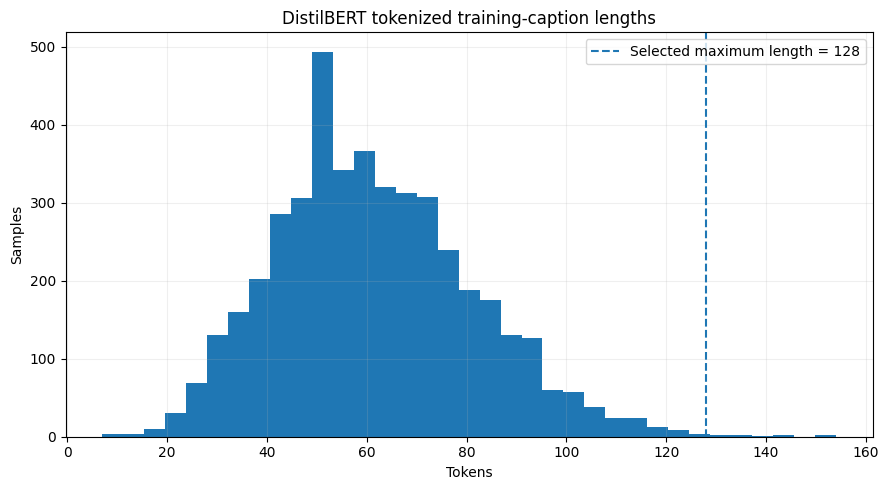

In [21]:
# CELL 21 - Token-length analysis and data-driven MAX_LENGTH

train_token_lengths = np.array([
    len(
        tokenizer.encode(
            text,
            add_special_tokens=True,
            truncation=False,
        )
    )
    for text in train_df["caption"].tolist()
])

p99 = float(
    np.quantile(
        train_token_lengths,
        0.99,
    )
)

MAX_LENGTH = 128 if p99 <= 128 else 256

print("Training token-length summary:")
print(pd.Series(train_token_lengths).describe())
print("\n99th percentile:", p99)
print("Selected MAX_LENGTH:", MAX_LENGTH)

for candidate in [128, 256]:
    truncated = int(
        (train_token_lengths > candidate).sum()
    )
    print(
        f"Would exceed {candidate}: "
        f"{truncated}/{len(train_token_lengths)} "
        f"({truncated/len(train_token_lengths):.2%})"
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(train_token_lengths, bins=35)
ax.axvline(
    MAX_LENGTH,
    linestyle="--",
    label=f"Selected maximum length = {MAX_LENGTH}",
)
ax.set_title("DistilBERT tokenized training-caption lengths")
ax.set_xlabel("Tokens")
ax.set_ylabel("Samples")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "token_length_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

In [22]:
# CELL 22 - PyTorch Dataset

class MusicCapsTextDataset(Dataset):
    def __init__(
        self,
        frame,
        labels,
        tokenizer,
        max_length,
    ):
        self.texts = frame["caption"].tolist()
        self.labels = labels.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

        if len(self.texts) != len(self.labels):
            raise ValueError(
                "Text count and label count differ."
            )

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        item = {
            key: value.squeeze(0)
            for key, value in encoded.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.float32,
        )

        return item

train_dataset = MusicCapsTextDataset(
    train_df,
    Y_train,
    tokenizer,
    MAX_LENGTH,
)
val_dataset = MusicCapsTextDataset(
    val_df,
    Y_val,
    tokenizer,
    MAX_LENGTH,
)
test_dataset = MusicCapsTextDataset(
    test_df,
    Y_test,
    tokenizer,
    MAX_LENGTH,
)

sample = train_dataset[0]

print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))

print("\nEncoded sample shapes:")
for key, value in sample.items():
    print(key, tuple(value.shape), value.dtype)

print("\nCaption:")
print(train_df.iloc[0]["caption"])

print("\nOriginal MusicCaps aspects:")
print(train_df.iloc[0]["aspects"])

print("\nRetained proxy labels:")
print([
    id_to_tag[i]
    for i, value in enumerate(Y_train[0])
    if value == 1
])

Train/Val/Test: 4438 503 580

Encoded sample shapes:
input_ids (128,) torch.int64
attention_mask (128,) torch.int64
labels (62,) torch.float32

Caption:
The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.

Original MusicCaps aspects:
['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']

Retained proxy labels:
['low quality']


In [23]:
# CELL 23 - DataLoaders

pin_memory = DEVICE.type == "cuda"
num_workers = 2 if os.name != "nt" else 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

batch = next(iter(train_loader))

print("\nFirst batch:")
for key, value in batch.items():
    print(key, tuple(value.shape))

Train batches: 139
Val batches  : 16
Test batches : 19

First batch:
input_ids (32, 128)
attention_mask (32, 128)
labels (32, 62)


# Metrics and simple baselines

The main classification metrics are:

Micro F1 score

Macro F1 score

Mean Area Under the Precision Recall Curve

Micro precision

Micro recall

Two simple sanity baselines are also evaluated.

In [24]:
# CELL 24 - Metric functions

def safe_mean_auc_pr(y_true, y_prob):
    scores = []

    for k in range(y_true.shape[1]):
        # AP is meaningful only when the evaluated split has a positive example.
        if y_true[:, k].sum() > 0:
            scores.append(
                average_precision_score(
                    y_true[:, k],
                    y_prob[:, k],
                )
            )

    return float(np.mean(scores)) if scores else float("nan")


def multilabel_metrics(y_true, y_prob, threshold=0.5):
    """
    Compute both micro and macro classification metrics.

    threshold can be:
      - scalar: one global threshold for every label
      - array-like with shape [num_labels]: one validation-calibrated threshold per label
    """
    threshold_array = np.asarray(threshold)

    if threshold_array.ndim == 0:
        y_pred = (y_prob >= float(threshold_array)).astype(int)
    else:
        if threshold_array.shape[0] != y_prob.shape[1]:
            raise ValueError("Per-label threshold count does not match number of labels.")
        y_pred = (y_prob >= threshold_array.reshape(1, -1)).astype(int)

    return {
        "micro_f1": f1_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "micro_precision": precision_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "micro_recall": recall_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "mean_auc_pr": safe_mean_auc_pr(y_true, y_prob),
        "true_positive_rate": float(y_true.mean()),
        "predicted_positive_rate": float(y_pred.mean()),
        "true_positive_count": int(y_true.sum()),
        "predicted_positive_count": int(y_pred.sum()),
    }

print("Metric helpers ready.")

Metric helpers ready.


In [25]:
# CELL 25 - Simple prevalence baseline

train_prevalence = Y_train.mean(axis=0)
prevalence_prob = np.tile(
    train_prevalence,
    (len(Y_test), 1),
)

all_zero_prob = np.zeros_like(
    Y_test,
    dtype=np.float32,
)

baseline_df = pd.DataFrame([
    {
        "model": "all-zero",
        "threshold": 0.5,
        **multilabel_metrics(
            Y_test,
            all_zero_prob,
            0.5,
        ),
    },
    {
        "model": "train-prevalence",
        "threshold": 0.10,
        **multilabel_metrics(
            Y_test,
            prevalence_prob,
            0.10,
        ),
    },
])

display(baseline_df)

baseline_df.to_csv(
    METRICS_DIR / "task1_simple_baselines.csv",
    index=False,
)

,model,threshold,micro_f1,macro_f1,micro_precision,micro_recall,macro_precision,macro_recall,mean_auc_pr,true_positive_rate,predicted_positive_rate,true_positive_count,predicted_positive_count
0,all-zero,0.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.048304,0.048304,0.000000,1737,0
1,train-prevalence,0.1,0.188028,0.026378,0.134236,0.313759,0.015156,0.112903,0.048304,0.048304,0.112903,1737,4060


# DistilBERT model

The model is DistilBERT with one multi label classification head.

Every output label is independent, so sigmoid probabilities and binary cross entropy loss are used.

In [26]:
# CELL 26 - Build DistilBERT on the verified device

print("Building:", MODEL_NAME)
print("Device:", DEVICE)
print("Number of labels:", NUM_LABELS)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification",
)

model.config.id2label = {
    i: id_to_tag[i]
    for i in range(NUM_LABELS)
}
model.config.label2id = {
    tag: i
    for i, tag in id_to_tag.items()
}

model = model.to(DEVICE)

# Real model forward preflight.
test_encoding = tokenizer(
    train_df.iloc[0]["caption"],
    return_tensors="pt",
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH,
)
test_encoding = {
    k: v.to(DEVICE)
    for k, v in test_encoding.items()
}

model.eval()
with torch.no_grad():
    test_logits = model(
        **test_encoding
    ).logits

print("Forward preflight succeeded.")
print("Logits shape:", tuple(test_logits.shape))
print("Logits device:", test_logits.device)

del test_encoding, test_logits

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

total_params = sum(
    p.numel()
    for p in model.parameters()
)
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Building: distilbert-base-uncased
Device: cuda
Number of labels: 62


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Forward preflight succeeded.
Logits shape: (1, 62)
Logits device: cuda:0
Total parameters    : 67,001,150
Trainable parameters: 67,001,150


In [27]:
# CELL 27 - BCE loss

criterion = nn.BCEWithLogitsLoss()

print("Loss:", criterion)
print("This matches the BCE multi-label objective required by Task 1.")

Loss: BCEWithLogitsLoss()
This matches the BCE multi-label objective required by Task 1.


In [28]:
# CELL 28 - Optimizer, scheduler, AMP

actual_epochs = (
    FAST_DEV_EPOCHS
    if FAST_DEV_RUN
    else EPOCHS
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = (
    len(train_loader)
    * actual_epochs
)

warmup_steps = int(
    WARMUP_RATIO
    * total_steps
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

amp_enabled = DEVICE.type == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=amp_enabled,
)

print("Epochs       :", actual_epochs)
print("Steps        :", total_steps)
print("Warmup steps :", warmup_steps)
print("Learning rate:", LEARNING_RATE)
print("AMP          :", amp_enabled)

Epochs       : 10
Steps        : 1390
Warmup steps : 139
Learning rate: 2e-05
AMP          : True


In [29]:
# CELL 29 - Device-safe training helpers

def move_batch(batch):
    return {
        key: value.to(
            DEVICE,
            non_blocking=(
                DEVICE.type == "cuda"
            ),
        )
        for key, value in batch.items()
    }

def autocast_context():
    if DEVICE.type == "cuda":
        return torch.amp.autocast(
            "cuda",
            enabled=True,
        )
    return nullcontext()

def train_one_epoch(model, loader):
    model.train()

    losses = []
    report_every = max(
        1,
        len(loader) // 5,
    )

    for step, batch in enumerate(
        loader,
        1,
    ):
        batch = move_batch(batch)
        labels = batch.pop("labels")

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast_context():
            logits = model(**batch).logits
            loss = criterion(
                logits,
                labels,
            )

        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )

            scaler.step(optimizer)
            scaler.update()

        else:
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )

            optimizer.step()

        scheduler.step()

        losses.append(
            loss.item()
        )

        if (
            step == 1
            or step % report_every == 0
            or step == len(loader)
        ):
            print(
                f"  step {step:>4}/{len(loader)} | "
                f"loss={loss.item():.4f} | "
                f"lr={scheduler.get_last_lr()[0]:.2e} | "
                f"device={DEVICE}"
            )

    return float(
        np.mean(losses)
    )

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()

    losses = []
    probs = []
    labels = []

    for batch in loader:
        batch = move_batch(batch)
        y = batch.pop("labels")

        with autocast_context():
            logits = model(**batch).logits
            loss = criterion(
                logits,
                y,
            )

        probability = torch.sigmoid(
            logits
        )

        losses.append(
            loss.item()
        )
        probs.append(
            probability
            .detach()
            .float()
            .cpu()
            .numpy()
        )
        labels.append(
            y.detach()
            .float()
            .cpu()
            .numpy()
        )

    return (
        float(np.mean(losses)),
        np.concatenate(
            labels,
            axis=0,
        ),
        np.concatenate(
            probs,
            axis=0,
        ),
    )

print("Training helpers ready.")

Training helpers ready.


# Fine tune DistilBERT

The model is trained for a maximum of 10 epochs.

The best epoch is selected using validation mean Area Under the Precision Recall Curve.

The best parameters are kept only in memory during this notebook run. They are not saved in the final GitHub folder.

In [30]:
# CELL 30  Training loop with validation based model selection

history = []

best_validation_mean_auc_pr = -np.inf
best_epoch = -1
epochs_without_improvement = 0
best_state_dict = None

print("=" * 72)
print("START TRAINING")
print("=" * 72)
print("Best epoch is selected using validation mean Area Under the Precision Recall Curve.")
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)

for epoch in range(1, actual_epochs + 1):
    print()
    print("=" * 72)
    print(f"Epoch {epoch} of {actual_epochs}")
    print("=" * 72)

    train_loss = train_one_epoch(
        model,
        train_loader,
    )

    validation_loss, validation_true, validation_probability = predict_loader(
        model,
        val_loader,
    )

    metrics = multilabel_metrics(
        validation_true,
        validation_probability,
        threshold=0.5,
    )

    row = {
        "epoch": epoch,
        "training_loss": train_loss,
        "validation_loss": validation_loss,
        "validation_micro_f1_score_at_threshold_0_5": metrics["micro_f1"],
        "validation_macro_f1_score_at_threshold_0_5": metrics["macro_f1"],
        "validation_mean_area_under_precision_recall_curve": metrics["mean_auc_pr"],
        "validation_micro_precision_at_threshold_0_5": metrics["micro_precision"],
        "validation_micro_recall_at_threshold_0_5": metrics["micro_recall"],
        "validation_macro_precision_at_threshold_0_5": metrics["macro_precision"],
        "validation_macro_recall_at_threshold_0_5": metrics["macro_recall"],
        "validation_true_positive_rate": metrics["true_positive_rate"],
        "validation_predicted_positive_rate_at_threshold_0_5": metrics["predicted_positive_rate"],
    }

    history.append(row)

    print("Epoch summary")
    print("Training loss:", f"{train_loss:.4f}")
    print("Validation loss:", f"{validation_loss:.4f}")
    print("Validation Micro F1 score at threshold 0.5:", f"{metrics['micro_f1']:.4f}")
    print("Validation Macro F1 score at threshold 0.5:", f"{metrics['macro_f1']:.4f}")
    print(
        "Validation mean Area Under the Precision Recall Curve:",
        f"{metrics['mean_auc_pr']:.4f}",
    )

    current_score = metrics["mean_auc_pr"]

    if current_score > best_validation_mean_auc_pr + 1e-6:
        best_validation_mean_auc_pr = current_score
        best_epoch = epoch
        epochs_without_improvement = 0

        best_state_dict = {
            name: value.detach().cpu().clone()
            for name, value in model.state_dict().items()
        }

        print(
            "Best model in memory updated at Epoch",
            epoch,
            "with validation mean Area Under the Precision Recall Curve",
            f"{current_score:.4f}",
        )
    else:
        epochs_without_improvement += 1

        print(
            "No validation improvement for",
            epochs_without_improvement,
            "Epoch",
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history)

history_df.to_csv(
    METRICS_DIR / "training_history.csv",
    index=False,
)

if best_state_dict is None:
    raise RuntimeError("No best model state was recorded.")

model.load_state_dict(best_state_dict)
best_model = model
best_model.eval()

print()
print("Training complete.")
print("Best Epoch:", best_epoch)
print(
    "Best validation mean Area Under the Precision Recall Curve:",
    f"{best_validation_mean_auc_pr:.4f}",
)

display(history_df)

START TRAINING
Best epoch is selected using validation mean Area Under the Precision Recall Curve.
Early stopping patience: 2

Epoch 1 of 10
  step    1/139 | loss=0.7008 | lr=1.44e-07 | device=cuda
  step   27/139 | loss=0.6859 | lr=3.88e-06 | device=cuda
  step   54/139 | loss=0.5969 | lr=7.77e-06 | device=cuda
  step   81/139 | loss=0.4943 | lr=1.17e-05 | device=cuda
  step  108/139 | loss=0.4018 | lr=1.55e-05 | device=cuda
  step  135/139 | loss=0.3118 | lr=1.94e-05 | device=cuda
  step  139/139 | loss=0.2987 | lr=2.00e-05 | device=cuda
Epoch summary
Training loss: 0.5312
Validation loss: 0.2966
Validation Micro F1 score at threshold 0.5: 0.0000
Validation Macro F1 score at threshold 0.5: 0.0000
Validation mean Area Under the Precision Recall Curve: 0.1259
Best model in memory updated at Epoch 1 with validation mean Area Under the Precision Recall Curve 0.1259

Epoch 2 of 10
  step    1/139 | loss=0.2794 | lr=2.00e-05 | device=cuda
  step   27/139 | loss=0.2355 | lr=1.96e-05 | devi

,epoch,training_loss,validation_loss,validation_micro_f1_score_at_threshold_0_5,validation_macro_f1_score_at_threshold_0_5,validation_mean_area_under_precision_recall_curve,validation_micro_precision_at_threshold_0_5,validation_micro_recall_at_threshold_0_5,validation_macro_precision_at_threshold_0_5,validation_macro_recall_at_threshold_0_5,validation_true_positive_rate,validation_predicted_positive_rate_at_threshold_0_5
0,1,0.531242,0.296573,0.000000,0.000000,0.125883,0.000000,0.000000,0.000000,0.000000,0.052492,0.000000
1,2,0.212935,0.187114,0.000000,0.000000,0.188013,0.000000,0.000000,0.000000,0.000000,0.052492,0.000000
2,3,0.169706,0.163203,0.108170,0.015471,0.284953,0.930693,0.057422,0.015161,0.015793,0.052492,0.003239
3,4,0.149549,0.147059,0.277463,0.076162,0.368415,0.890728,0.164325,0.136993,0.060818,0.052492,0.009684
4,5,0.134666,0.135298,0.332012,0.112671,0.425386,0.879265,0.204643,0.207496,0.088444,0.052492,0.012217
5,6,0.124694,0.128184,0.415164,0.169974,0.454231,0.853612,0.274282,0.233488,0.144816,0.052492,0.016867
6,7,0.118248,0.122706,0.446847,0.196014,0.476822,0.850772,0.302993,0.276652,0.164499,0.052492,0.018694
7,8,0.113125,0.119413,0.457650,0.203413,0.491998,0.834951,0.315211,0.315712,0.177815,0.052492,0.019817
8,9,0.109896,0.117135,0.457551,0.205522,0.499909,0.851913,0.312767,0.316469,0.177597,0.052492,0.019271
9,10,0.108227,0.116412,0.473128,0.219230,0.504035,0.848341,0.328039,0.359273,0.189030,0.052492,0.020298


# Training plots

Use these plots in the report.

Loss curves show optimization stability.

Micro F1 score and Macro F1 score show classification performance across Epochs.

Mean Area Under the Precision Recall Curve is the threshold independent checkpoint metric.

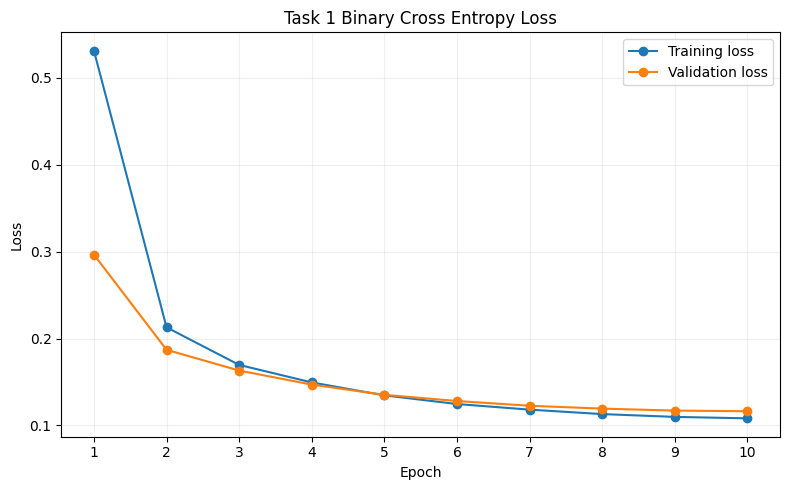

In [31]:
# CELL 31  Training and validation loss

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_df["epoch"],
    history_df["training_loss"],
    marker="o",
    label="Training loss",
)

ax.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation loss",
)

ax.set_title("Task 1 Binary Cross Entropy Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(history_df["epoch"])
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    PLOTS_DIR / "loss_curve.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

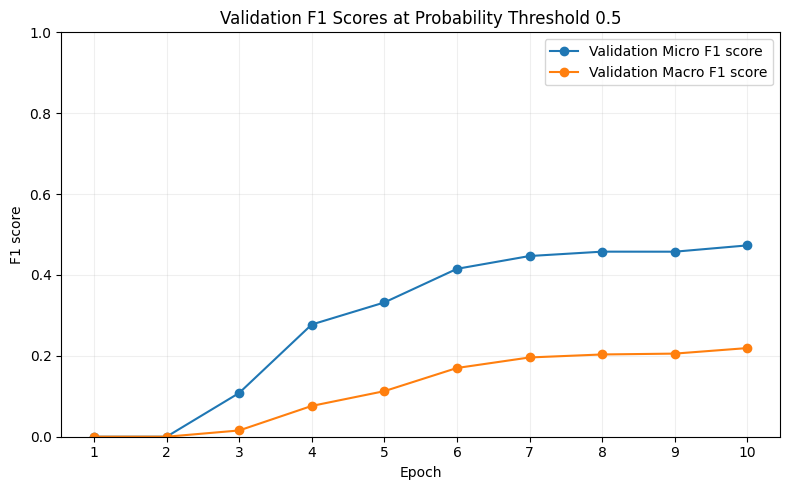

In [32]:
# CELL 32  Validation Micro F1 score and Macro F1 score

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_df["epoch"],
    history_df["validation_micro_f1_score_at_threshold_0_5"],
    marker="o",
    label="Validation Micro F1 score",
)

ax.plot(
    history_df["epoch"],
    history_df["validation_macro_f1_score_at_threshold_0_5"],
    marker="o",
    label="Validation Macro F1 score",
)

ax.set_title("Validation F1 Scores at Probability Threshold 0.5")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
ax.set_xticks(history_df["epoch"])
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    PLOTS_DIR / "f1_curves.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

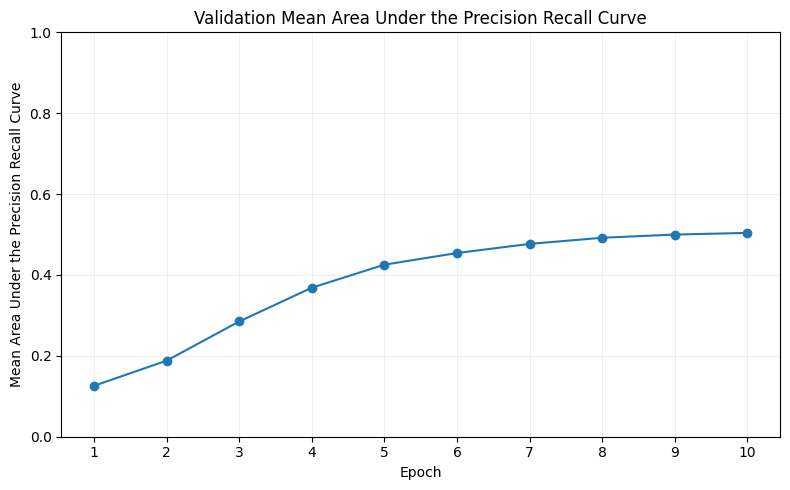

In [33]:
# CELL 33  Validation mean Area Under the Precision Recall Curve

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_df["epoch"],
    history_df["validation_mean_area_under_precision_recall_curve"],
    marker="o",
)

ax.set_title("Validation Mean Area Under the Precision Recall Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Area Under the Precision Recall Curve")
ax.set_ylim(0, 1)
ax.set_xticks(history_df["epoch"])
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    PLOTS_DIR / "area_under_precision_recall_curve.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

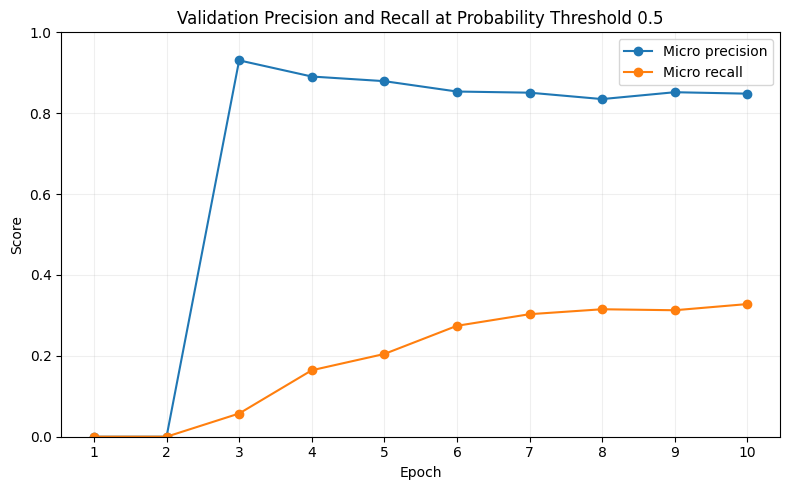

In [34]:
# CELL 34  Validation Micro Precision and Micro Recall

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_df["epoch"],
    history_df["validation_micro_precision_at_threshold_0_5"],
    marker="o",
    label="Micro precision",
)

ax.plot(
    history_df["epoch"],
    history_df["validation_micro_recall_at_threshold_0_5"],
    marker="o",
    label="Micro recall",
)

ax.set_title("Validation Precision and Recall at Probability Threshold 0.5")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xticks(history_df["epoch"])
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    PLOTS_DIR / "precision_recall_curve_by_epoch.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Select the probability threshold

The default probability threshold 0.5 is only a reference.

The main operating threshold is selected using validation Micro F1 score only.

The test set is not used for threshold selection.

Best global probability threshold selected by validation Micro F1 score: 0.27
Validation Micro F1 score: 0.5837163493105713
Validation Macro F1 score at this threshold: 0.36814565004247757


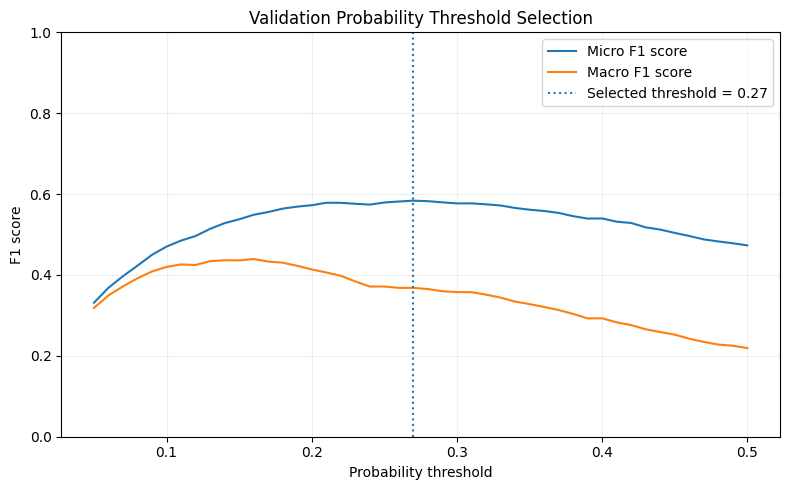

In [35]:
# CELL 35  Select one global probability threshold using validation data

validation_loss_best, validation_true_best, validation_probability_best = predict_loader(
    best_model,
    val_loader,
)

GLOBAL_THRESHOLD_GRID = np.arange(0.05, 0.501, 0.01)

threshold_rows = []

for threshold in GLOBAL_THRESHOLD_GRID:
    metrics = multilabel_metrics(
        validation_true_best,
        validation_probability_best,
        float(threshold),
    )

    threshold_rows.append({
        "threshold": float(threshold),
        "micro_f1_score": metrics["micro_f1"],
        "macro_f1_score": metrics["macro_f1"],
        "micro_precision": metrics["micro_precision"],
        "micro_recall": metrics["micro_recall"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "predicted_positive_rate": metrics["predicted_positive_rate"],
        "true_positive_rate": metrics["true_positive_rate"],
    })

threshold_df = pd.DataFrame(threshold_rows)

best_micro_row = threshold_df.loc[
    threshold_df["micro_f1_score"].idxmax()
]

BEST_GLOBAL_THRESHOLD = float(
    best_micro_row["threshold"]
)

best_macro_row = threshold_df.loc[
    threshold_df["macro_f1_score"].idxmax()
]

BEST_GLOBAL_THRESHOLD_MACRO = float(
    best_macro_row["threshold"]
)

print(
    "Best global probability threshold selected by validation Micro F1 score:",
    BEST_GLOBAL_THRESHOLD,
)

print(
    "Validation Micro F1 score:",
    float(best_micro_row["micro_f1_score"]),
)

print(
    "Validation Macro F1 score at this threshold:",
    float(best_micro_row["macro_f1_score"]),
)

threshold_df.to_csv(
    METRICS_DIR / "validation_global_threshold_search.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    threshold_df["threshold"],
    threshold_df["micro_f1_score"],
    label="Micro F1 score",
)

ax.plot(
    threshold_df["threshold"],
    threshold_df["macro_f1_score"],
    label="Macro F1 score",
)

ax.axvline(
    BEST_GLOBAL_THRESHOLD,
    linestyle=":",
    label=f"Selected threshold = {BEST_GLOBAL_THRESHOLD:.2f}",
)

ax.set_title("Validation Probability Threshold Selection")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    PLOTS_DIR / "validation_threshold_selection.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Optional per label threshold analysis

A separate validation threshold is also tested for each label.

This is only a secondary analysis because rare labels have fewer validation examples.

Use the single global validation threshold as the main Task 1 result.

In [36]:
# CELL 35B - Per-label validation threshold calibration

PER_LABEL_GRID = np.arange(0.05, 0.801, 0.01)

PER_LABEL_THRESHOLDS = np.full(
    NUM_LABELS,
    BEST_GLOBAL_THRESHOLD,
    dtype=np.float32,
)

per_label_rows = []

for k, tag in enumerate(selected_tags):
    y_true_k = validation_true_best[:, k].astype(int)
    prob_k = validation_probability_best[:, k]

    # All retained labels should have training support; validation support can still be small.
    # If a label has zero validation positives, keep the global threshold rather than inventing
    # a threshold from no positive evidence.
    if y_true_k.sum() == 0:
        best_t = BEST_GLOBAL_THRESHOLD
        best_f1 = np.nan
    else:
        candidates = []

        for t in PER_LABEL_GRID:
            pred_k = (prob_k >= t).astype(int)
            f1_k = f1_score(
                y_true_k,
                pred_k,
                zero_division=0,
            )
            candidates.append((float(t), float(f1_k)))

        best_f1 = max(x[1] for x in candidates)

        # Stable tie-break: among equally good thresholds, choose the one closest
        # to the primary global threshold.
        tied = [
            x for x in candidates
            if abs(x[1] - best_f1) < 1e-12
        ]
        best_t = min(
            tied,
            key=lambda x: abs(x[0] - BEST_GLOBAL_THRESHOLD),
        )[0]

    PER_LABEL_THRESHOLDS[k] = best_t

    per_label_rows.append({
        "label_id": k,
        "tag": tag,
        "validation_support": int(y_true_k.sum()),
        "threshold": float(best_t),
        "best_validation_label_f1": (
            float(best_f1) if not np.isnan(best_f1) else np.nan
        ),
    })

per_label_threshold_df = pd.DataFrame(per_label_rows)

val_metrics_global = multilabel_metrics(
    validation_true_best,
    validation_probability_best,
    BEST_GLOBAL_THRESHOLD,
)

val_metrics_per_label = multilabel_metrics(
    validation_true_best,
    validation_probability_best,
    PER_LABEL_THRESHOLDS,
)

print("=" * 95)
print("VALIDATION THRESHOLD COMPARISON")
print("=" * 95)
print("Global threshold:", BEST_GLOBAL_THRESHOLD)
print(
    "Global     -> "
    f"Micro F1 score={val_metrics_global['micro_f1']:.4f} | "
    f"Macro F1 score={val_metrics_global['macro_f1']:.4f} | "
    f"Micro precision={val_metrics_global['micro_precision']:.4f} | "
    f"Micro recall={val_metrics_global['micro_recall']:.4f}"
)
print(
    "Per-label  -> "
    f"Micro F1 score={val_metrics_per_label['micro_f1']:.4f} | "
    f"Macro F1 score={val_metrics_per_label['macro_f1']:.4f} | "
    f"Micro precision={val_metrics_per_label['micro_precision']:.4f} | "
    f"Micro recall={val_metrics_per_label['micro_recall']:.4f}"
)

display(per_label_threshold_df)

per_label_threshold_df.to_csv(
    METRICS_DIR / "validation_per_label_thresholds.csv",
    index=False,
)

VALIDATION THRESHOLD COMPARISON
Global threshold: 0.27
Global     -> Micro F1 score=0.5837 | Macro F1 score=0.3681 | Micro precision=0.6309 | Micro recall=0.5431
Per-label  -> Micro F1 score=0.5811 | Macro F1 score=0.5507 | Micro precision=0.4928 | Micro recall=0.7080


,label_id,tag,validation_support,threshold,best_validation_label_f1
0,0,low quality,96,0.71,0.994764
1,1,instrumental,95,0.28,0.857143
2,2,emotional,59,0.43,0.713043
3,3,noisy,58,0.48,0.878505
4,4,energetic,61,0.27,0.625000
...,...,...,...,...,...
57,57,melodic singing,15,0.17,0.650000
58,58,electronic music,12,0.09,0.375000
59,59,groovy bass line,13,0.16,0.518519
60,60,medium to uptempo,10,0.07,0.231884


# Final held out test evaluation

After the best Epoch and probability thresholds are fixed, the test set is evaluated once.

The main result uses the single global threshold selected with validation Micro F1 score.

In [37]:
# CELL 36 - Final held-out test metrics

test_loss, test_true, test_prob = predict_loader(
    best_model,
    test_loader,
)

# 1) conventional reference cutoff
test_at_05 = multilabel_metrics(
    test_true,
    test_prob,
    threshold=0.5,
)

# 2) PRIMARY result: one global threshold chosen by validation Micro-F1
test_at_global = multilabel_metrics(
    test_true,
    test_prob,
    threshold=BEST_GLOBAL_THRESHOLD,
)

# 3) SECONDARY calibrated analysis: per-label thresholds chosen on validation only
test_at_per_label = multilabel_metrics(
    test_true,
    test_prob,
    threshold=PER_LABEL_THRESHOLDS,
)

final_test_df = pd.DataFrame([
    {
        "setting": "DistilBERT at probability threshold 0.50",
        "threshold": "0.50",
        "test_loss": test_loss,
        **test_at_05,
    },
    {
        "setting": "DistilBERT at validation selected global threshold PRIMARY",
        "threshold": f"{BEST_GLOBAL_THRESHOLD:.2f}",
        "test_loss": test_loss,
        **test_at_global,
    },
    {
        "setting": "DistilBERT at validation selected per label thresholds SECONDARY",
        "threshold": "per-label",
        "test_loss": test_loss,
        **test_at_per_label,
    },
])

print("=" * 115)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 115)
print(
    "PRIMARY result uses one global validation-selected threshold. "
    "Per-label calibration is a secondary analysis."
)
display(final_test_df)

final_test_df.to_csv(
    METRICS_DIR / "final_test_metrics.csv",
    index=False,
)

with open(
    METRICS_DIR / "final_metrics.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "checkpoint_selection": "validation mean AUC-PR",
            "best_validation_mean_auc_pr": float(best_validation_mean_auc_pr),
            "primary_global_threshold": float(BEST_GLOBAL_THRESHOLD),
            "test_loss": float(test_loss),
            "test_at_0_5": {
                k: float(v) for k, v in test_at_05.items()
            },
            "test_at_primary_global_threshold": {
                k: float(v) for k, v in test_at_global.items()
            },
            "test_at_validation_per_label_thresholds": {
                k: float(v) for k, v in test_at_per_label.items()
            },
        },
        f,
        indent=2,
    )

print("Saved final_test_metrics.csv and final_metrics.json")

FINAL HELD-OUT TEST RESULTS
PRIMARY result uses one global validation-selected threshold. Per-label calibration is a secondary analysis.


,setting,threshold,test_loss,micro_f1,macro_f1,micro_precision,micro_recall,macro_precision,macro_recall,mean_auc_pr,true_positive_rate,predicted_positive_rate,true_positive_count,predicted_positive_count
0,DistilBERT at probability threshold 0.50,0.50,0.105162,0.497115,0.212026,0.875181,0.347150,0.331518,0.176797,0.501977,0.048304,0.019160,1737,689
1,DistilBERT at validation selected global thres...,0.27,0.105162,0.599198,0.363495,0.645612,0.559010,0.380378,0.386460,0.501977,0.048304,0.041824,1737,1504
2,DistilBERT at validation selected per label th...,per-label,0.105162,0.559667,0.489678,0.487201,0.657455,0.488698,0.575586,0.501977,0.048304,0.065184,1737,2344


Saved final_test_metrics.csv and final_metrics.json


In [38]:
# CELL 37 - Per-label test metrics

test_pred_global = (
    test_prob >= BEST_GLOBAL_THRESHOLD
).astype(int)

test_pred_calibrated = (
    test_prob >= PER_LABEL_THRESHOLDS.reshape(1, -1)
).astype(int)

rows = []

for i, tag in enumerate(selected_tags):
    y_true_k = test_true[:, i].astype(int)
    prob_k = test_prob[:, i]

    pred_global_k = test_pred_global[:, i]
    pred_cal_k = test_pred_calibrated[:, i]

    ap = (
        average_precision_score(
            y_true_k,
            prob_k,
        )
        if y_true_k.sum() > 0
        else np.nan
    )

    rows.append({
        "label_id": i,
        "tag": tag,
        "train_support": int(Y_train[:, i].sum()),
        "val_support": int(Y_val[:, i].sum()),
        "test_support": int(y_true_k.sum()),
        "global_threshold": float(BEST_GLOBAL_THRESHOLD),
        "per_label_threshold": float(PER_LABEL_THRESHOLDS[i]),
        "precision_global": precision_score(
            y_true_k, pred_global_k, zero_division=0
        ),
        "recall_global": recall_score(
            y_true_k, pred_global_k, zero_division=0
        ),
        "f1_global": f1_score(
            y_true_k, pred_global_k, zero_division=0
        ),
        "precision_calibrated": precision_score(
            y_true_k, pred_cal_k, zero_division=0
        ),
        "recall_calibrated": recall_score(
            y_true_k, pred_cal_k, zero_division=0
        ),
        "f1_calibrated": f1_score(
            y_true_k, pred_cal_k, zero_division=0
        ),
        "auc_pr": ap,
    })

per_tag_df = pd.DataFrame(rows).sort_values(
    ["f1_global", "test_support"],
    ascending=[False, False],
)

display(per_tag_df)

per_tag_df.to_csv(
    METRICS_DIR / "per_tag_test_metrics.csv",
    index=False,
)

print("\nTop 10 labels by primary global threshold F1 score:")
display(per_tag_df.head(10))

print("\nBottom 10 labels by primary global threshold F1 score:")
display(
    per_tag_df
    .sort_values("f1_global")
    .head(10)
)

,label_id,tag,train_support,val_support,test_support,global_threshold,per_label_threshold,precision_global,recall_global,f1_global,precision_calibrated,recall_calibrated,f1_calibrated,auc_pr
0,0,low quality,980,96,141,0.27,0.71,0.921569,1.000000,0.959184,0.992806,0.978723,0.985714,0.999015
3,3,noisy,490,58,78,0.27,0.48,0.797872,0.961538,0.872093,0.971831,0.884615,0.926174,0.966908
30,30,male vocal,170,24,14,0.27,0.11,0.812500,0.928571,0.866667,0.371429,0.928571,0.530612,0.702805
46,46,fun,123,17,20,0.27,0.15,0.941176,0.800000,0.864865,0.850000,0.850000,0.850000,0.861357
1,1,instrumental,723,95,89,0.27,0.28,0.810000,0.910112,0.857143,0.826531,0.910112,0.866310,0.909644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53,53,no other instruments,109,15,13,0.27,0.13,0.000000,0.000000,0.000000,0.473684,0.692308,0.562500,0.548469
58,58,electronic music,103,12,13,0.27,0.09,0.000000,0.000000,0.000000,0.151515,0.384615,0.217391,0.091410
59,59,groovy bass line,103,13,10,0.27,0.16,0.000000,0.000000,0.000000,0.222222,0.400000,0.285714,0.288181
61,61,vibrant,101,10,7,0.27,0.06,0.000000,0.000000,0.000000,0.063830,0.428571,0.111111,0.209003



Top 10 labels by primary global threshold F1 score:


,label_id,tag,train_support,val_support,test_support,global_threshold,per_label_threshold,precision_global,recall_global,f1_global,precision_calibrated,recall_calibrated,f1_calibrated,auc_pr
0,0,low quality,980,96,141,0.27,0.71,0.921569,1.000000,0.959184,0.992806,0.978723,0.985714,0.999015
3,3,noisy,490,58,78,0.27,0.48,0.797872,0.961538,0.872093,0.971831,0.884615,0.926174,0.966908
30,30,male vocal,170,24,14,0.27,0.11,0.812500,0.928571,0.866667,0.371429,0.928571,0.530612,0.702805
46,46,fun,123,17,20,0.27,0.15,0.941176,0.800000,0.864865,0.850000,0.850000,0.850000,0.861357
1,1,instrumental,723,95,89,0.27,0.28,0.810000,0.910112,0.857143,0.826531,0.910112,0.866310,0.909644
23,23,happy,180,22,23,0.27,0.16,0.894737,0.739130,0.809524,0.800000,0.869565,0.833333,0.905602
17,17,instrumental music,203,18,25,0.27,0.34,0.718750,0.920000,0.807018,0.880000,0.880000,0.880000,0.928183
12,12,mono,287,26,44,0.27,0.50,0.651515,0.977273,0.781818,0.975000,0.886364,0.928571,0.984980
25,25,punchy kick,179,23,34,0.27,0.35,0.659091,0.852941,0.743590,0.676471,0.676471,0.676471,0.761013
21,21,punchy snare,184,23,28,0.27,0.32,0.600000,0.964286,0.739726,0.702703,0.928571,0.800000,0.783818



Bottom 10 labels by primary global threshold F1 score:


,label_id,tag,train_support,val_support,test_support,global_threshold,per_label_threshold,precision_global,recall_global,f1_global,precision_calibrated,recall_calibrated,f1_calibrated,auc_pr
29,29,percussion,171,19,16,0.27,0.14,0.0,0.0,0.0,0.235294,0.250000,0.242424,0.247580
49,49,cheerful,114,20,16,0.27,0.13,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.136031
54,54,intense,106,12,16,0.27,0.10,0.0,0.0,0.0,0.214286,0.187500,0.200000,0.270451
39,39,upbeat,144,22,15,0.27,0.10,0.0,0.0,0.0,0.192308,0.333333,0.243902,0.201593
42,42,loud,133,20,15,0.27,0.05,0.0,0.0,0.0,0.078947,0.600000,0.139535,0.078426
45,45,keyboard harmony,126,19,15,0.27,0.10,0.0,0.0,0.0,0.234043,0.733333,0.354839,0.352567
47,47,easygoing,122,18,14,0.27,0.12,0.0,0.0,0.0,0.200000,0.142857,0.166667,0.145734
43,43,mellow,133,8,17,0.27,0.11,0.0,0.0,0.0,0.416667,0.294118,0.344828,0.252478
18,18,piano,190,26,23,0.27,0.10,0.0,0.0,0.0,0.240741,0.565217,0.337662,0.287692
51,51,e-guitar,110,23,14,0.27,0.16,0.0,0.0,0.0,0.526316,0.714286,0.606061,0.443438


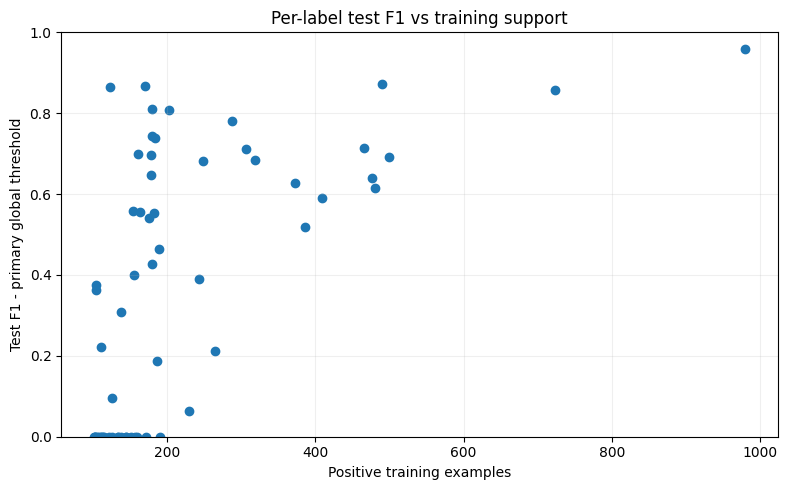

Pearson correlation: 0.5918663862483593


In [39]:
# CELL 38 - Training support vs per-label F1

analysis_df = per_tag_df.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    analysis_df["train_support"],
    analysis_df["f1_global"],
)
ax.set_title("Per-label test F1 vs training support")
ax.set_xlabel("Positive training examples")
ax.set_ylabel("Test F1 - primary global threshold")
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_support_vs_test_f1.png", dpi=180, bbox_inches="tight")
plt.show()

print(
    "Pearson correlation:",
    analysis_df[
        ["train_support", "f1_global"]
    ].corr().iloc[0, 1],
)

# Five prediction examples

Five test captions with at least one retained ground truth label are selected.

For each example the notebook saves the caption, original MusicCaps aspects, retained ground truth tags, predicted tags, and top five model probabilities.

In [40]:
# CELL 39 - Five meaningful held-out prediction examples

def decode_true(row):
    return [
        id_to_tag[i]
        for i, value in enumerate(row)
        if value == 1
    ]

def decode_thresholded(probabilities, threshold):
    ids = np.where(
        probabilities >= threshold
    )[0]

    ids = sorted(
        ids,
        key=lambda i: probabilities[i],
        reverse=True,
    )

    return [
        (id_to_tag[i], float(probabilities[i]))
        for i in ids
    ]

def decode_top_k(probabilities, k=5):
    ids = np.argsort(probabilities)[::-1][:k]

    return [
        (id_to_tag[i], float(probabilities[i]))
        for i in ids
    ]

# For the required qualitative examples, choose clips that have at least one retained
# ground-truth label. Zero-target clips remain in the actual test metrics above.
eligible_indices = np.where(
    test_true.sum(axis=1) > 0
)[0]

if len(eligible_indices) >= 5:
    positions = np.linspace(
        0,
        len(eligible_indices) - 1,
        5,
        dtype=int,
    )
    example_indices = eligible_indices[positions]
else:
    example_indices = eligible_indices

examples = []

for number, idx in enumerate(example_indices, 1):
    truth = decode_true(
        test_true[idx]
    )

    predictions = decode_thresholded(
        test_prob[idx],
        BEST_GLOBAL_THRESHOLD,
    )

    top5 = decode_top_k(
        test_prob[idx],
        k=5,
    )

    print("\n" + "=" * 110)
    print(f"EXAMPLE {number} | TEST INDEX {idx}")
    print("=" * 110)

    print("CAPTION:")
    print(test_df.iloc[idx]["caption"])

    print("\nORIGINAL MUSICCAPS ASPECTS:")
    print(test_df.iloc[idx]["aspects"])

    print("\nRETAINED GROUND-TRUTH TAGS:")
    print(truth)

    print(
        f"\nPRIMARY PREDICTED TAGS "
        f"(global validation threshold={BEST_GLOBAL_THRESHOLD:.2f}):"
    )
    print(
        predictions
        if predictions
        else "No retained tag crossed the primary threshold."
    )

    print("\nTOP FIVE MODEL SCORES (diagnostic; not forced predictions):")
    for rank, (tag, probability) in enumerate(top5, 1):
        print(f"{rank}. {tag} ({probability:.4f})")

    examples.append({
        "test_index": int(idx),
        "ytid": str(test_df.iloc[idx]["ytid"]),
        "start_s": int(test_df.iloc[idx]["start_s"]),
        "end_s": int(test_df.iloc[idx]["end_s"]),
        "caption": test_df.iloc[idx]["caption"],
        "original_aspects": test_df.iloc[idx]["aspects"],
        "true_retained_tags": truth,
        "primary_global_threshold": float(BEST_GLOBAL_THRESHOLD),
        "predicted_tags": predictions,
        "top5_model_scores": top5,
    })

with open(
    EXAMPLES_DIR / "five_prediction_examples.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        examples,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("\nSaved five_prediction_examples.json")


EXAMPLE 1 | TEST INDEX 0
CAPTION:
This song features an electric guitar as the main instrument. The guitar plays a descending run in the beginning then plays an arpeggiated chord followed by a double stop hammer on to a higher note and a descending slide followed by a descending chord run. The percussion plays a simple beat using rim shots. The percussion plays in common time. The bass plays only one note on the first count of each bar. The piano plays backing chords. There are no voices in this song. The mood of this song is relaxing. This song can be played in a coffee shop.

ORIGINAL MUSICCAPS ASPECTS:
['guitar song', 'piano backing', 'simple percussion', 'relaxing melody', 'slow tempo', 'bass', 'country feel', 'instrumental', 'no voice']

RETAINED GROUND-TRUTH TAGS:
['instrumental', 'slow tempo', 'bass']

PRIMARY PREDICTED TAGS (global validation threshold=0.27):
[('instrumental', 0.6689453125), ('no voices', 0.46435546875), ('moderate tempo', 0.431396484375)]

TOP FIVE MODEL SCOR

# Optional attention figure

One held out example is visualized using final layer DistilBERT attention.

This is only a qualitative visualization. It should not be described as a complete causal explanation of the prediction.

DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


This song features an electric guitar as the main instrument. The guitar plays a descending run in the beginning then plays an arpeggiated chord followed by a double stop hammer on to a higher note and a descending slide followed by a descending chord run. The percussion plays a simple beat using rim shots. The percussion plays in common time. The bass plays only one note on the first count of each bar. The piano plays backing chords. There are no voices in this song. The mood of this song is relaxing. This song can be played in a coffee shop.


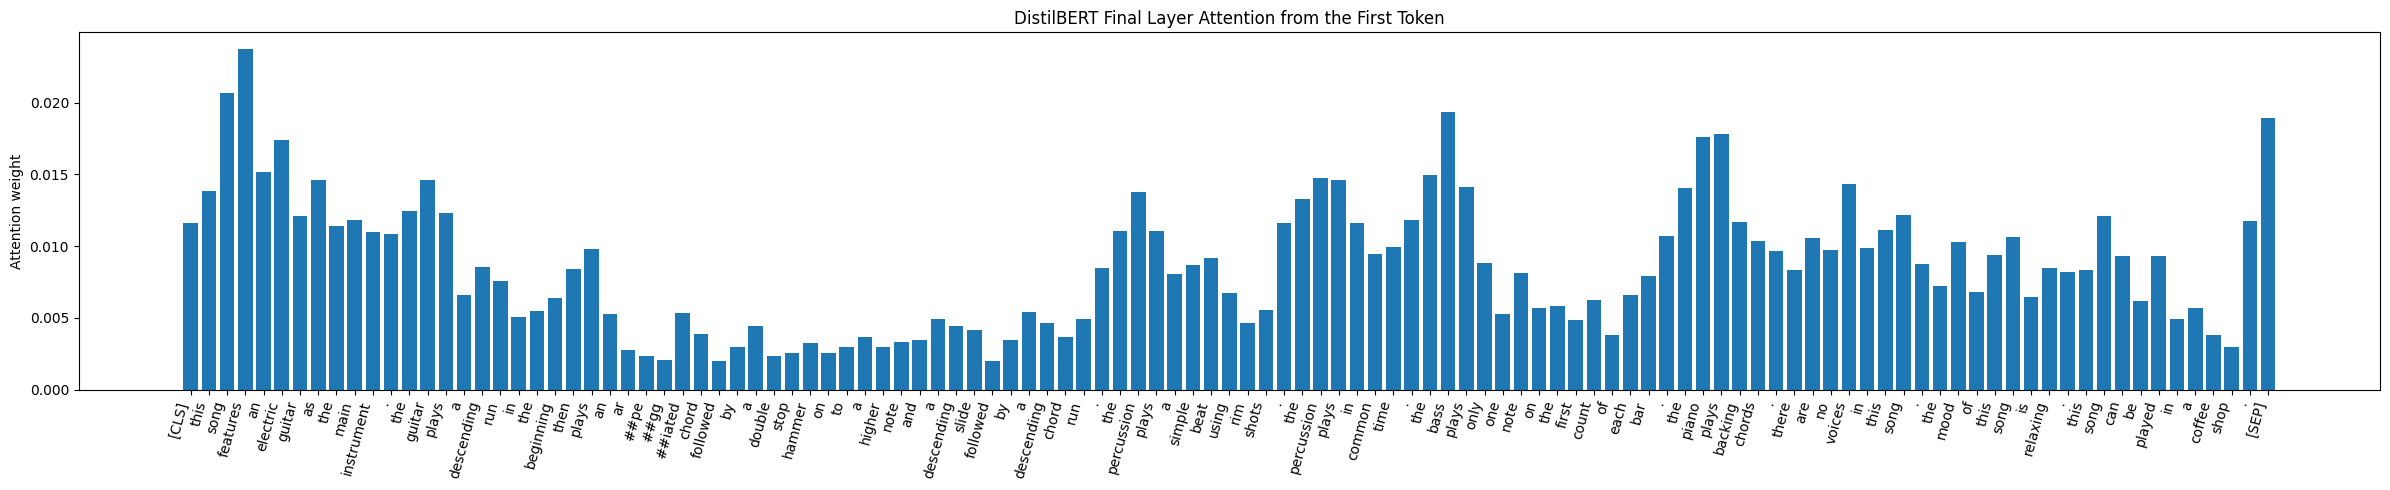

Top model probabilities
instrumental                        0.6693
no voices                           0.4648
moderate tempo                      0.4315
slow tempo                          0.2517
no other instruments                0.2188
bass                                0.2070
percussion                          0.1815
male voice                          0.1703
amateur recording                   0.1282
acoustic guitar                     0.1251


In [41]:
# CELL 40  Optional attention visualization

best_model.eval()

@torch.no_grad()
def visualize_attention(text):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    output = best_model(
        **encoded,
        output_attentions=True,
        return_dict=True,
    )

    probabilities = torch.sigmoid(
        output.logits
    )[0].float().cpu().numpy()

    last_attention = output.attentions[-1][0]

    first_token_attention = (
        last_attention[:, 0, :]
        .mean(dim=0)
        .float()
        .cpu()
        .numpy()
    )

    token_ids = encoded["input_ids"][0].cpu().tolist()
    attention_mask = (
        encoded["attention_mask"][0]
        .cpu()
        .numpy()
        .astype(bool)
    )

    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    tokens = [
        token
        for token, keep in zip(tokens, attention_mask)
        if keep
    ]

    scores = first_token_attention[attention_mask]

    fig, ax = plt.subplots(
        figsize=(max(12, min(24, len(tokens) * 0.45)), 5)
    )

    ax.bar(
        np.arange(len(tokens)),
        scores,
    )

    ax.set_xticks(np.arange(len(tokens)))
    ax.set_xticklabels(tokens, rotation=75, ha="right")
    ax.set_title("DistilBERT Final Layer Attention from the First Token")
    ax.set_ylabel("Attention weight")

    plt.tight_layout()
    plt.savefig(
        PLOTS_DIR / "attention_example.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    print("Top model probabilities")

    for index in np.argsort(probabilities)[::-1][:10]:
        print(
            f"{id_to_tag[index]:35s} "
            f"{probabilities[index]:.4f}"
        )

attention_index = int(example_indices[0])

print(test_df.iloc[attention_index]["caption"])

visualize_attention(
    test_df.iloc[attention_index]["caption"]
)

# Reusable prediction function

This function accepts a new text description and returns the predicted Task 1 tags.

In [42]:
# CELL 41 - End-to-end inference

@torch.no_grad()
def predict_tags_from_caption(
    caption,
    threshold=BEST_GLOBAL_THRESHOLD,
):
    best_model.eval()

    encoded = tokenizer(
        caption,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )

    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    logits = best_model(
        **encoded
    ).logits

    probs = torch.sigmoid(
        logits
    )[0].float().cpu().numpy()

    selected = np.where(
        probs >= threshold
    )[0]

    selected = sorted(
        selected,
        key=lambda i: probs[i],
        reverse=True,
    )

    if len(selected) == 0:
        selected = np.argsort(
            probs
        )[::-1][:5]

        print(
            "No tag crossed the selected threshold; "
            "showing top-5 probabilities."
        )

    return pd.DataFrame({
        "tag": [
            id_to_tag[i]
            for i in selected
        ],
        "probability": [
            float(probs[i])
            for i in selected
        ],
    })

demo_caption = (
    "A mellow piano melody plays slowly with a soft female vocal "
    "and an emotional ballad feel."
)

print("Demo caption:")
print(demo_caption)

display(
    predict_tags_from_caption(
        demo_caption
    )
)

Demo caption:
A mellow piano melody plays slowly with a soft female vocal and an emotional ballad feel.


,tag,probability
0,emotional,0.364908


# Save configuration and project documentation

The final folder contains everything needed to inspect the Task 1 experiment results.

Model weights are intentionally not saved.

In [43]:
# CELL 42  Save experiment configuration

manifest = {
    "experiment": "Task1 MusicCaps DistilBERT",
    "dataset": DATASET_NAME,
    "model": MODEL_NAME,
    "input": "caption",
    "target_source": "aspect_list",
    "target_preprocessing": "lowercase and whitespace normalization",
    "label_selection": f"training support at least {MIN_TRAIN_SUPPORT}",
    "number_of_labels": NUM_LABELS,
    "selected_tags": selected_tags,
    "split_method": (
        "80 10 10 iterative stratification using AudioSet positive labels "
        "for split balancing only"
    ),
    "loss": LOSS_NAME,
    "maximum_sequence_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "maximum_training_epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "checkpoint_selection": "validation mean Area Under the Precision Recall Curve",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "seed": SEED,
    "best_epoch": int(best_epoch),
    "best_validation_mean_area_under_precision_recall_curve": float(
        best_validation_mean_auc_pr
    ),
    "primary_global_probability_threshold": float(
        BEST_GLOBAL_THRESHOLD
    ),
    "model_weights_saved": False,
}

with open(
    CONFIG_DIR / "experiment_manifest.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        manifest,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(json.dumps(manifest, indent=2, ensure_ascii=False))

{
  "experiment": "Task1 MusicCaps DistilBERT",
  "dataset": "google/MusicCaps",
  "model": "distilbert-base-uncased",
  "input": "caption",
  "target_source": "aspect_list",
  "target_preprocessing": "lowercase and whitespace normalization",
  "label_selection": "training support at least 100",
  "number_of_labels": 62,
  "selected_tags": [
    "low quality",
    "instrumental",
    "emotional",
    "noisy",
    "energetic",
    "medium tempo",
    "passionate",
    "amateur recording",
    "slow tempo",
    "live performance",
    "acoustic drums",
    "fast tempo",
    "mono",
    "groovy",
    "bass guitar",
    "electric guitar",
    "acoustic guitar",
    "instrumental music",
    "piano",
    "moderate tempo",
    "uptempo",
    "punchy snare",
    "shimmering hi hats",
    "happy",
    "groovy bass",
    "punchy kick",
    "e-bass",
    "poor audio quality",
    "male voice",
    "percussion",
    "male vocal",
    "male singer",
    "no voices",
    "pop",
    "rock",
    "ele

In [44]:
# CELL 43  Create README, requirements, summary, and ZIP file

primary_result = final_test_df.iloc[1]

readme_text = f"""# Task 1 MusicCaps DistilBERT

# Goal

This Task 1 experiment uses DistilBERT to read MusicCaps natural language captions and predict multiple music context tags.

# Dataset

Dataset: Google MusicCaps

Total original examples: {len(work_df)}

Training examples: {len(train_df)}

Validation examples: {len(val_df)}

Test examples: {len(test_df)}

Number of retained target tags: {NUM_LABELS}

# Model

Text encoder: distilbert-base-uncased

Loss: Binary Cross Entropy with Logits

Maximum caption length: {MAX_LENGTH} tokens

Batch size: {BATCH_SIZE}

Maximum training epochs: {EPOCHS}

Best Epoch: {best_epoch}

# Main Test Result

Primary probability threshold: {BEST_GLOBAL_THRESHOLD:.2f}

Micro F1 score: {test_at_global["micro_f1"]:.4f}

Macro F1 score: {test_at_global["macro_f1"]:.4f}

Micro precision: {test_at_global["micro_precision"]:.4f}

Micro recall: {test_at_global["micro_recall"]:.4f}

Mean Area Under the Precision Recall Curve: {test_at_global["mean_auc_pr"]:.4f}

# Folder Contents

data_splits contains the training, validation, and test CSV files.

metrics contains training history, baselines, threshold search tables, final metrics, label support, and per tag metrics.

plots contains dataset, training, threshold, per label, and attention figures.

examples contains five qualitative prediction examples.

config contains the label mapping and experiment configuration.

# Important Notes

The main reported result uses one probability threshold selected using validation Micro F1 score.

The test set is used only after model and threshold choices are fixed.

Per label threshold calibration is a secondary analysis.

Model weights are not included because this project submission focuses on code, results, plots, and reproducibility.
"""

with open(
    PROJECT_DIR / "README.md",
    "w",
    encoding="utf-8",
) as file:
    file.write(readme_text)

requirements_text = """torch
datasets
transformers
accelerate
scikit-learn
iterative-stratification
numpy
pandas
matplotlib
"""

with open(
    PROJECT_DIR / "requirements.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(requirements_text)

summary_df = pd.DataFrame([
    {
        "dataset": DATASET_NAME,
        "model": MODEL_NAME,
        "number_of_labels": NUM_LABELS,
        "best_epoch": best_epoch,
        "validation_selected_probability_threshold": BEST_GLOBAL_THRESHOLD,
        "test_micro_f1_score": test_at_global["micro_f1"],
        "test_macro_f1_score": test_at_global["macro_f1"],
        "test_micro_precision": test_at_global["micro_precision"],
        "test_micro_recall": test_at_global["micro_recall"],
        "test_mean_area_under_precision_recall_curve": test_at_global["mean_auc_pr"],
    }
])

summary_df.to_csv(
    METRICS_DIR / "task1_main_result_summary.csv",
    index=False,
)

print("Project folder created:")
print(PROJECT_DIR)

print()
print("Files in project folder:")

for path in sorted(PROJECT_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(PROJECT_DIR))

zip_base = str(PROJECT_DIR.parent / "task1_musiccaps_github_download")

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    root_dir=PROJECT_DIR.parent,
    base_dir=PROJECT_DIR.name,
)

print()
print("ZIP file created:")
print(zip_path)

from IPython.display import FileLink, display

display(
    FileLink(zip_path)
)

Project folder created:
/kaggle/working/task1_musiccaps_github

Files in project folder:
README.md
config/experiment_manifest.json
config/label_mapping.json
data_splits/test_musiccaps_task1.csv
data_splits/train_musiccaps_task1.csv
data_splits/validation_musiccaps_task1.csv
examples/five_prediction_examples.json
metrics/final_metrics.json
metrics/final_test_metrics.csv
metrics/per_tag_test_metrics.csv
metrics/task1_label_support.csv
metrics/task1_main_result_summary.csv
metrics/task1_simple_baselines.csv
metrics/training_history.csv
metrics/validation_global_threshold_search.csv
metrics/validation_per_label_thresholds.csv
plots/area_under_precision_recall_curve.png
plots/aspect_frequency_top30.png
plots/aspects_per_sample.png
plots/attention_example.png
plots/caption_length_distribution.png
plots/f1_curves.png
plots/loss_curve.png
plots/precision_recall_curve_by_epoch.png
plots/token_length_distribution.png
plots/training_label_support_distribution.png
plots/training_support_vs_test_f1

/kaggle/working/task1_musiccaps_github_download.zip

In [45]:
# FINAL DOWNLOAD CELL FOR KAGGLE

import os
import shutil
from pathlib import Path
from IPython.display import FileLink, display

PROJECT_FOLDER = Path("/kaggle/working/task1_musiccaps_github")
ZIP_NAME = "task1_musiccaps_github_download.zip"
ZIP_PATH = Path("/kaggle/working") / ZIP_NAME

# Remove an old ZIP if it already exists
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# Create ZIP containing the complete Task 1 folder
shutil.make_archive(
    "/kaggle/working/task1_musiccaps_github_download",
    "zip",
    root_dir="/kaggle/working",
    base_dir="task1_musiccaps_github",
)

print("ZIP created successfully")
print("ZIP path:", ZIP_PATH)
print("ZIP size:", f"{ZIP_PATH.stat().st_size / (1024**2):.2f} MB")

# IMPORTANT:
# Change current directory to /kaggle/working
# and give FileLink only the relative filename.
os.chdir("/kaggle/working")

print("\nClick the link below to download the complete Task 1 folder:")
display(FileLink(ZIP_NAME))

ZIP created successfully
ZIP path: /kaggle/working/task1_musiccaps_github_download.zip
ZIP size: 1.90 MB

Click the link below to download the complete Task 1 folder:


/kaggle/working/task1_musiccaps_github_download.zip